In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Load image and apply edge detection
def load_and_edge_detection(image_path):
    # Read image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Built-in edge detection (Canny)
    edges_canny = cv2.Canny(blurred, 100, 200)
    
    # User-defined edge detection (Sobel operators)
    def custom_edge_detection(image):
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        sobelx_abs = np.uint8(np.absolute(sobelx))
        sobely_abs = np.uint8(np.absolute(sobely))
        _, edges_x = cv2.threshold(sobelx_abs, 50, 255, cv2.THRESH_BINARY)
        _, edges_y = cv2.threshold(sobely_abs, 50, 255, cv2.THRESH_BINARY)
        edges_combined = cv2.bitwise_or(edges_x, edges_y)
        return edges_x, edges_y, edges_combined
    
    edges_sobel_x, edges_sobel_y, edges_sobel_combined = custom_edge_detection(blurred)
    
    # Display edges
    plt.figure(figsize=(12, 8))
    plt.subplot(231), plt.imshow(edges_canny, cmap='gray'), plt.title('Canny Edges')
    plt.subplot(232), plt.imshow(edges_sobel_x, cmap='gray'), plt.title('Sobel X (Vertical)')
    plt.subplot(233), plt.imshow(edges_sobel_y, cmap='gray'), plt.title('Sobel Y (Horizontal)')
    plt.subplot(234), plt.imshow(edges_sobel_combined, cmap='gray'), plt.title('Sobel Combined')
    plt.show()
    
    return img, edges_canny

In [4]:
# 2. Identify largest object boundary
def find_largest_boundary(edges):
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    largest_contour = max(contours, key=cv2.contourArea)
    return largest_contour

In [5]:
# 3. Compute 4-directional chain code
def compute_chain_code(contour):
    chain = []
    points = contour.reshape(-1, 2)
    n = points.shape[0]
    for i in range(n):
        x1, y1 = points[i]
        x2, y2 = points[(i+1)%n]
        dx = x2 - x1
        dy = y2 - y1
        
        # Determine direction
        if abs(dx) > abs(dy):
            direction = 0 if dx > 0 else 2
        else:
            direction = 1 if dy < 0 else 3
        chain.append(direction)
    return chain

In [6]:
# 4. Shape descriptor and 5. Classification
def classify_shape(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0
    
    # Vertex count
    epsilon = 0.04 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    vertices = len(approx)
    
    # Aspect ratio
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / float(h)
    
    # Classification
    if circularity > 0.85:
        return "Circle"
    elif vertices == 3:
        return "Triangle"
    elif vertices == 4:
        return "Square" if 0.9 <= aspect_ratio <= 1.1 else "Rectangle"
    else:
        return "Unknown"


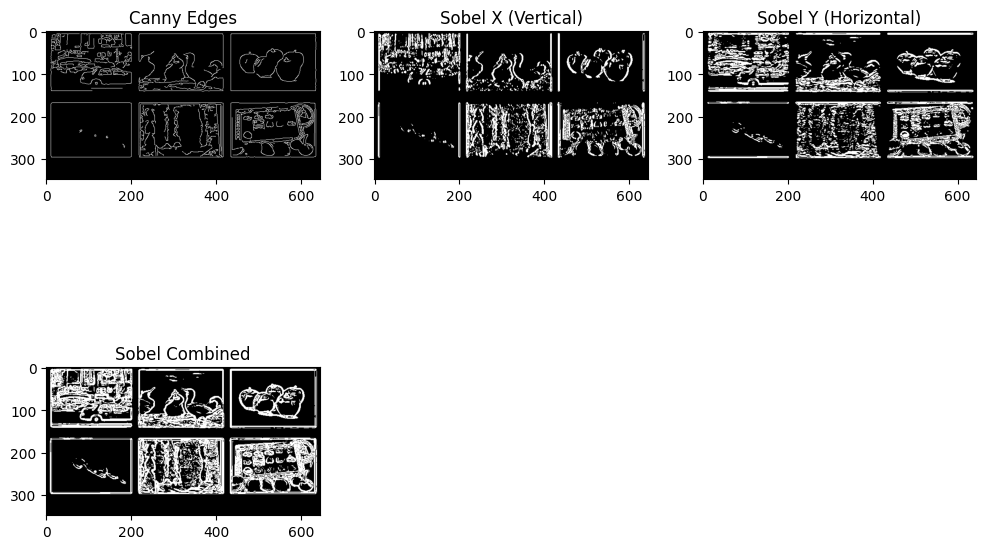

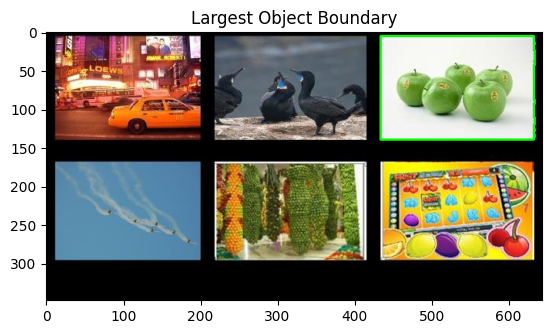

Chain Code (first 20 directions): [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Detected Shape: Rectangle


In [12]:
# Main execution
if __name__ == "__main__":
    image_path = 'multipleobjects.jpg'  # Replace with your image path
    img, edges = load_and_edge_detection(image_path)
    
    # Process largest object
    largest_contour = find_largest_boundary(edges)
    
    # Draw boundary
    img_contour = img.copy()
    cv2.drawContours(img_contour, [largest_contour], -1, (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
    plt.title('Largest Object Boundary'), plt.show()
    
    # Chain code
    chain_code = compute_chain_code(largest_contour)
    print("Chain Code (first 20 directions):", chain_code[:20])
    
    # Shape classification
    shape = classify_shape(largest_contour)
    print("Detected Shape:", shape)